# Aprendizaje profundo: Definición de una red neuronal Multicapa
## Actividad 1

## Estudiante: Edwin Silva Salas

## Etapa 1: Carga de los datos.

Cargamos la base de datos de interés seleccionada para esta actividad: Fashion MNIST, utilizando tf.keras.datasets.fashion_mnist.load_data(). Esta base de datos se usa para clasificación de imágenes en 10 clases de prendas de vestir (por ejemplo: camiseta, pantalón, pulóver, vestido, abrigo, sandalia, camisa, zapatilla, bolso y botín). Está compuesta por 60 000 imágenes de entrenamiento y 10 000 de prueba, en escala de grises y tamaño de 28x28 píxeles.
Referencia: https://keras.io/api/datasets/fashion_mnist/

Se cargan las librerías necesarias

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense   
from keras.utils import plot_model

Se carga la base de datos y se divide en los conjuntos de entrenamiento y prueba. En Fashion MNIST hay 60.000 imágenes para entrenamiento y 10.000 para prueba, todas en escala de grises y de tamaño 28x28 píxeles. Esta división permite evaluar qué tan bien generaliza el modelo con datos nuevos que no vio durante el entrenamiento.

In [46]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

In [47]:
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


# Etapa 2: Visualización de los datos

A continuación, se visualizan algunas imágenes del conjunto de entrenamiento para comprender la naturaleza de los datos y sus clases.

Las imágenes de **Fashion MNIST** tienen tamaño **28x28 píxeles** y un solo canal en **escala de grises**, por lo que cada muestra tiene dimensión **28x28**.

En la siguiente sección se presentan algunos ejemplos del conjunto de entrenamiento:

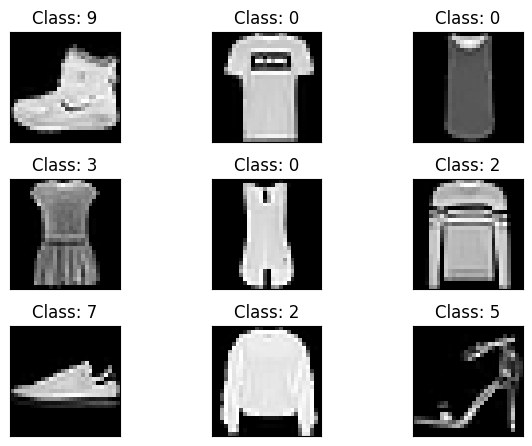

In [48]:
fig = plt.figure()
for i in range(9):
  plt.subplot(3,3,i+1)
  plt.tight_layout()
  plt.imshow(x_train[i], cmap='gray', interpolation='none')
  plt.title("Class: {}".format(y_train[i]))
  plt.xticks([])
  plt.yticks([])

En esta sección podemos visualizar mucho mejor las imagenes anteriormente mostradas

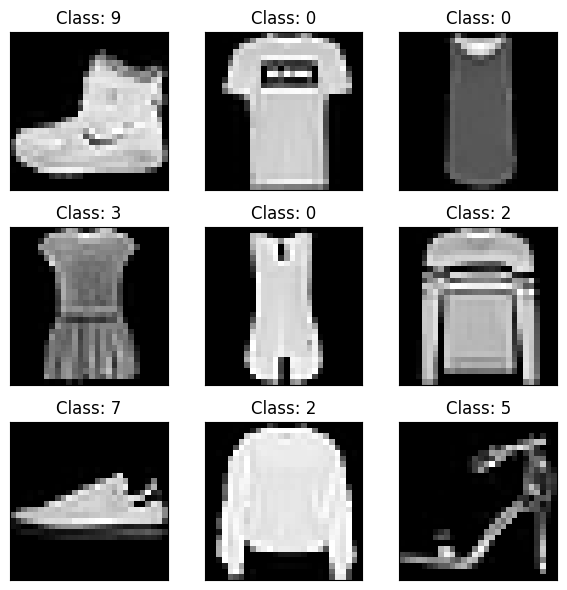

In [49]:
fig = plt.figure(figsize=(6,6))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Class: {y_train[i]}")
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()

# Etapa 3: Preprocesamiento de los datos

Como las redes neuronales densas trabajan con vectores y no directamente con imágenes, primero se realiza un “aplanamiento” (*flatten*). En **Fashion MNIST**, cada imagen tiene tamaño **28x28** en escala de grises, por lo que cada imagen se transforma en un vector de **784 valores** (28 x 28).

Además, los valores de los píxeles se normalizan al rango **[0,1]**, dividiendo entre 255. Este paso hace que el entrenamiento sea más estable y eficiente, ya que la red aprende mejor cuando los datos están en una escala homogénea y manejable.

In [50]:
# 2) Normalización
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 3) Versión para CNN (agregar canal: 28x28x1)
x_train_cnn = x_train[..., None]
x_test_cnn = x_test[..., None]

# Etapa 4: Definición del modelo usando API funcional
En esta etapa se definió un modelo de red neuronal para clasificar imágenes de la base de datos Fashion-MNIST (10 clases de prendas). Se utilizó la API funcional de Keras porque brinda mayor flexibilidad que la API secuencial para diseñar la arquitectura, controlar el flujo de datos entre capas y facilitar futuras mejoras del modelo.

In [51]:
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten
from tensorflow.keras.models import Model

def build_model_fc(dense_units_1, dense_units_2, activation, dropout_rate=0.3):

    # Fashion-MNIST para fully-connected: entrada 28x28
    inputs = Input(shape=(28, 28))

    # Aplanar imagen -> vector
    x = Flatten()(inputs)

    # Capas fully-connected
    x = Dense(dense_units_1, activation=activation)(x)
    x = Dropout(dropout_rate)(x)

    x = Dense(dense_units_2, activation=activation)(x)
    x = Dropout(dropout_rate)(x)

    outputs = Dense(10, activation="softmax")(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model

# Etapa 5: Búsqueda de hiperparámetros (Random Search)

Para optimizar el modelo en Fashion-MNIST se implementó una búsqueda aleatoria de hiperparámetros (Random Search). Dado que el costo computacional de evaluar todas las combinaciones es alto, se definió un espacio de búsqueda acotado y se evaluaron N configuraciones seleccionadas aleatoriamente.

Con el fin de mantener la viabilidad experimental en CPU, cada configuración se entrenó con un número reducido de épocas y criterio de parada temprana (Early Stopping). Esta estrategia permite comparar configuraciones de manera eficiente sin comprometer la validez del análisis.

Finalmente, se seleccionó la mejor configuración según accuracy de validación y se reportó su desempeño en el conjunto de prueba.

Referencia: Fashion MNIST dataset, an alternative to MNIST.

In [52]:
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibilidad
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

# Espacio de búsqueda para red fully-connected
search_space = {
    'dense_units_1': [128, 256, 512],
    'dense_units_2': [64, 128, 256],
    'activation': ['relu'],
    'dropout_rate': [0.2, 0.3],
    'learning_rate': [1e-3, 5e-4]
}

n_iter = 10
epochs = 10

# Condicion solicitada: batch_size = cantidad de datos de entrenamiento
full_batch_size = len(x_train)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=2,
    mode='max',
    restore_best_weights=True
)

results = []

for i in range(n_iter):
    params = {
        'dense_units_1': random.choice(search_space['dense_units_1']),
        'dense_units_2': random.choice(search_space['dense_units_2']),
        'activation': random.choice(search_space['activation']),
        'dropout_rate': random.choice(search_space['dropout_rate']),
        'learning_rate': random.choice(search_space['learning_rate']),
        'batch_size': full_batch_size,
    }

    print(f"Combinacion de prueba {i + 1}: {params}")

    model = build_model_fc(
        params['dense_units_1'],
        params['dense_units_2'],
        params['activation'],
        params['dropout_rate']
    )

    optimizer = tf.keras.optimizers.Adam(learning_rate=params['learning_rate'])

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train, y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=full_batch_size,
        callbacks=[early_stop],
        verbose=0
    )

    # mejor val_accuracy alcanzado en esa corrida
    best_val_acc = max(history.history['val_accuracy'])

    results.append({
        **params,
        'best_val_acc': best_val_acc
    })

    print(f"Combinacion de prueba {i + 1}: {results[i]['best_val_acc']:.4f} Accuracy")

# Ordenar de mejor a peor por validación
results = sorted(results, key=lambda x: x['best_val_acc'], reverse=True)





Combinacion de prueba 1: {'dense_units_1': 512, 'dense_units_2': 64, 'activation': 'relu', 'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 60000}
Combinacion de prueba 1: 0.7143 Accuracy
Combinacion de prueba 2: {'dense_units_1': 512, 'dense_units_2': 256, 'activation': 'relu', 'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 60000}
Combinacion de prueba 2: 0.5577 Accuracy
Combinacion de prueba 3: {'dense_units_1': 512, 'dense_units_2': 64, 'activation': 'relu', 'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 60000}
Combinacion de prueba 3: 0.6158 Accuracy
Combinacion de prueba 4: {'dense_units_1': 128, 'dense_units_2': 64, 'activation': 'relu', 'dropout_rate': 0.3, 'learning_rate': 0.0005, 'batch_size': 60000}
Combinacion de prueba 4: 0.2860 Accuracy
Combinacion de prueba 5: {'dense_units_1': 128, 'dense_units_2': 128, 'activation': 'relu', 'dropout_rate': 0.3, 'learning_rate': 0.0005, 'batch_size': 60000}
Combinacion de prueba 5: 0.2233 Accuracy
Combin

# Etapa 6: Selección del mejor modelo

Se elige la configuración de hiperparámetros que logró el mayor accuracy en el conjunto de prueba, para usarla luego en los siguientes experimentos.

In [53]:
print("Top 5 configuraciones:")
for r in results[:5]:
    print(r)

best_params = results[0]
print("\nMejor configuración:", best_params)

Top 5 configuraciones:
{'dense_units_1': 512, 'dense_units_2': 64, 'activation': 'relu', 'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 60000, 'best_val_acc': 0.7142500281333923}
{'dense_units_1': 512, 'dense_units_2': 64, 'activation': 'relu', 'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 60000, 'best_val_acc': 0.6158333420753479}
{'dense_units_1': 512, 'dense_units_2': 256, 'activation': 'relu', 'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 60000, 'best_val_acc': 0.5576666593551636}
{'dense_units_1': 256, 'dense_units_2': 64, 'activation': 'relu', 'dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 60000, 'best_val_acc': 0.5494999885559082}
{'dense_units_1': 256, 'dense_units_2': 128, 'activation': 'relu', 'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 60000, 'best_val_acc': 0.5249999761581421}

Mejor configuración: {'dense_units_1': 512, 'dense_units_2': 64, 'activation': 'relu', 'dropout_rate': 0.3, 'learning_rate': 0.001, 'b

# Etapa 7: Entrenamiento del mejor modelo

Se entrena de nuevo el modelo usando la mejor configuración encontrada, para ver cómo se comporta durante el proceso de aprendizaje.

In [54]:
# 1) Construir modelo fully-connected con los hiperparametros ganadores
best_model = build_model_fc(
    best_params['dense_units_1'],
    best_params['dense_units_2'],
    best_params['activation'],
    best_params['dropout_rate']
)

# 2) Compilar con learning rate ganador
best_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3) EarlyStopping (opcional, recomendado)
early_stop_final = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    mode='max',
    restore_best_weights=True
)

# 4) Entrenar con batch_size = cantidad total de datos de entrenamiento
history = best_model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=40,
    batch_size=len(x_train),
    callbacks=[early_stop_final],
    verbose=1
)

# 5) Evaluar en test
test_loss, test_acc = best_model.evaluate(x_test, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Epoch 1/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.1110 - loss: 2.4196 - val_accuracy: 0.3102 - val_loss: 2.0348
Epoch 2/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.2486 - loss: 2.0776 - val_accuracy: 0.5435 - val_loss: 1.7598
Epoch 3/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.4090 - loss: 1.8229 - val_accuracy: 0.5878 - val_loss: 1.5074
Epoch 4/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.4807 - loss: 1.6058 - val_accuracy: 0.5971 - val_loss: 1.3027
Epoch 5/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.5072 - loss: 1.4418 - val_accuracy: 0.6088 - val_loss: 1.1330
Epoch 6/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.5280 - loss: 1.3093 - val_accuracy: 0.6275 - val_loss: 1.0182
Epoch 7/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.5565 - loss: 1.2102 - val_accuracy: 0.6515 - val_loss: 0.9456
Epoch 8/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.5720 - loss: 1.1552 - val_accuracy: 0.6664 - val_loss: 0.

In [55]:
test_loss, test_acc = best_model.evaluate(x_test, y_test, verbose=0)

print("Test accuracy:", test_acc)

Test accuracy: 0.8215000033378601


# Etapa 8: Gráficas de desempeño

Se grafican las curvas de accuracy y de pérdida tanto para entrenamiento como para prueba, para ver cómo se comporta el modelo.

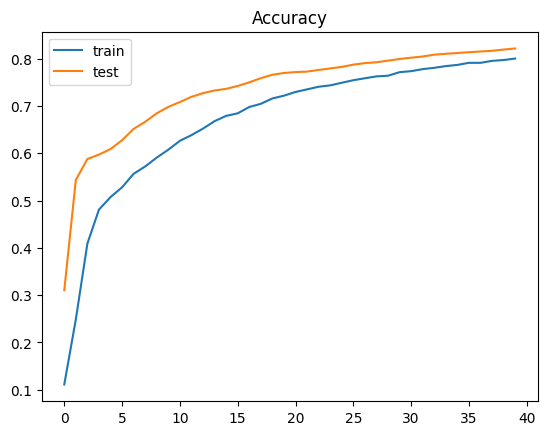

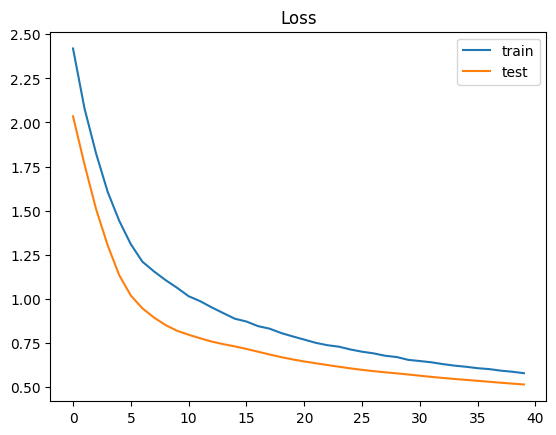

In [56]:
# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['train', 'test'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['train', 'test'])
plt.show()

# Etapa 9: Análisis del learning rate

En esta etapa se analiza cómo influye el learning rate en el entrenamiento del modelo, probando distintos valores y viendo cómo afectan la convergencia.


Learning rate: 0.0001


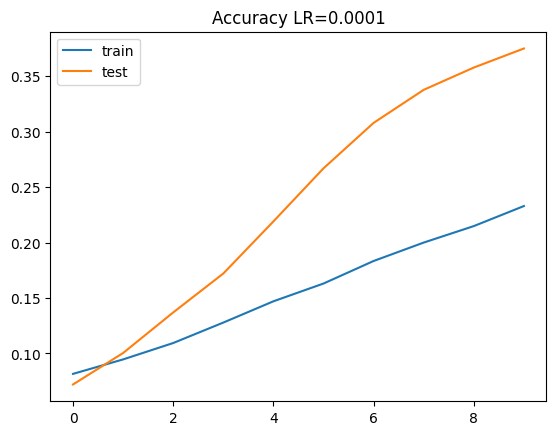

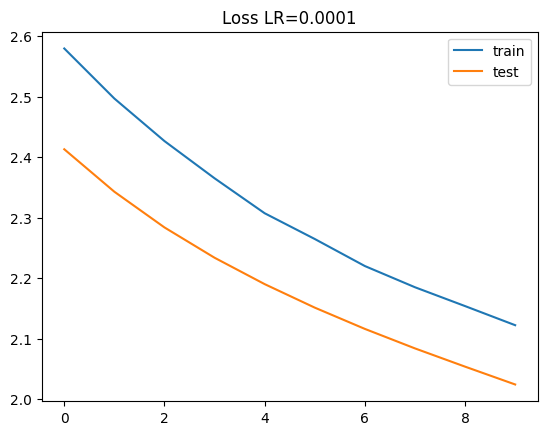


Learning rate: 0.01


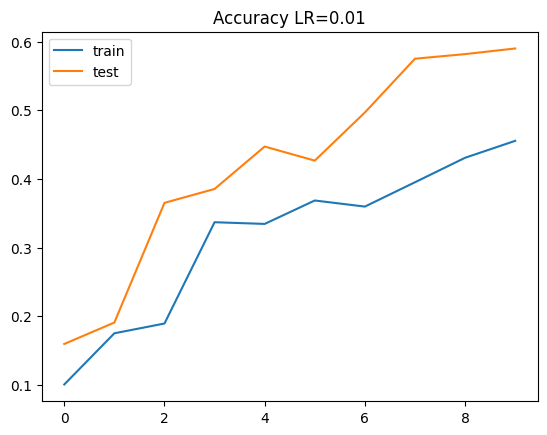

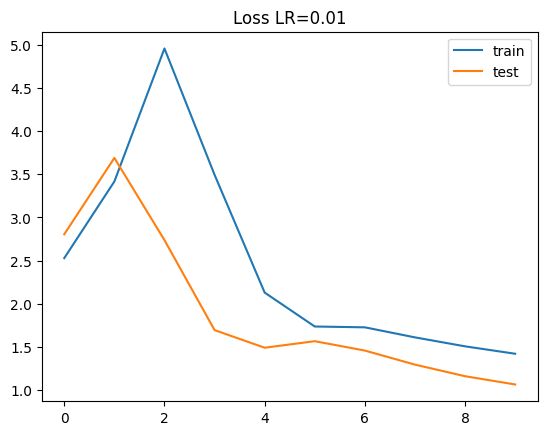


Learning rate: 0.1


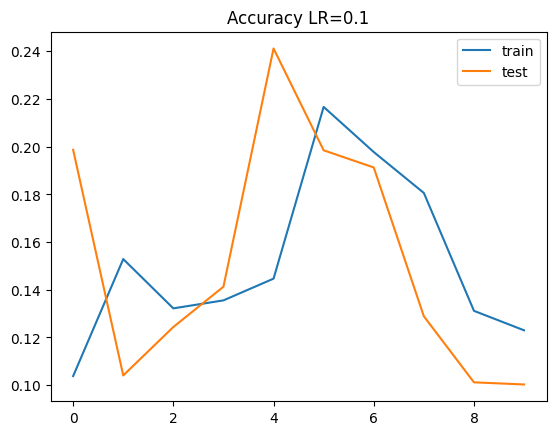

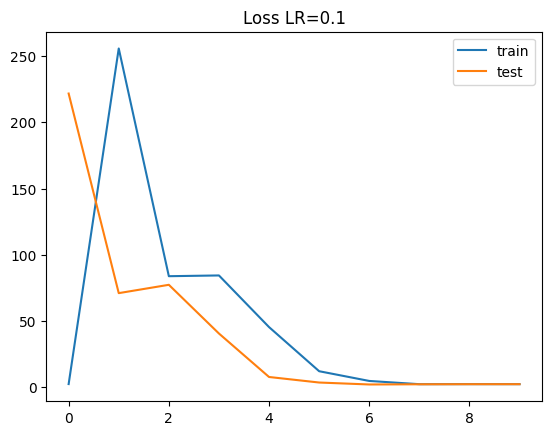


Learning rate: 1.0


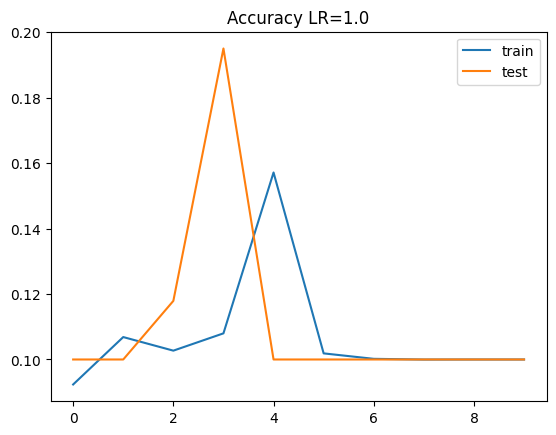

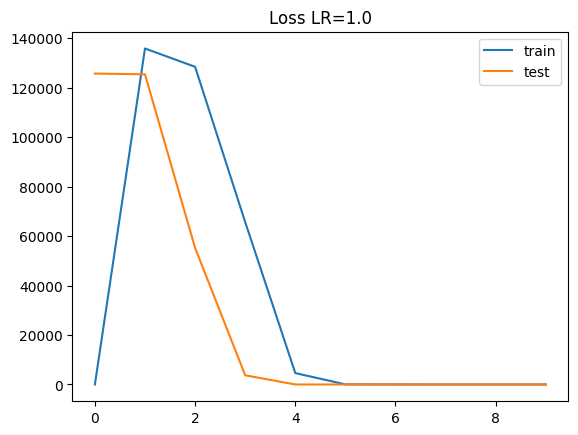


Learning rate: 10.0


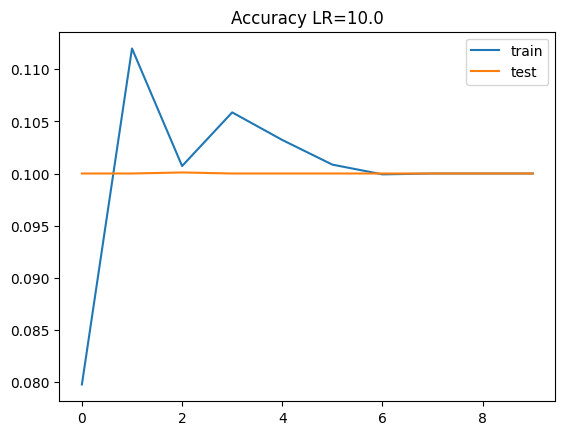

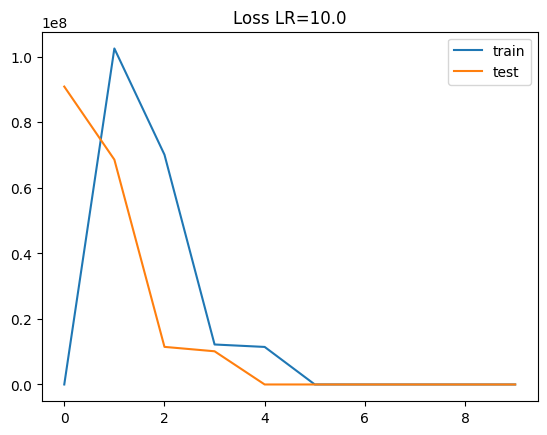

In [57]:
import numpy as np

learning_rates = [0.0001, 0.01, 0.1, 1.0, 10.0]

for lr in learning_rates:
    print(f"\nLearning rate: {lr}")

    model = build_model_fc(
        best_params['dense_units_1'],
        best_params['dense_units_2'],
        best_params['activation'],
        best_params['dropout_rate']
    )

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train, y_train,
        epochs=10,
        batch_size=len(x_train),
        validation_data=(x_test, y_test),
        verbose=0
    )

    # Check for NaN values in loss or accuracy history
    if np.isnan(history.history['loss'][-1]) or np.isnan(history.history['accuracy'][-1]):
        print(f"Warning: Training for LR={lr} resulted in NaN loss or accuracy. Skipping plots.")
        continue  # Skip plotting for this learning rate

    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='test')
    plt.title(f'Accuracy LR={lr}')
    plt.legend()
    plt.show()

    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='test')
    plt.title(f'Loss LR={lr}')
    plt.legend()
    plt.show()

En esta etapa se evaluó la sensibilidad del proceso de entrenamiento del modelo respecto al *learning rate* (η), mediante la experimentación con valores de 0.0001, 0.01, 0.1, 1.0 y 10.0.

Para valores muy bajos como 0.0001, el proceso de optimización presenta una convergencia lenta. La función de pérdida disminuye de forma gradual y la precisión (*accuracy*) mejora de manera incremental. Aunque el entrenamiento es estable, el tamaño de paso en el espacio de parámetros es demasiado pequeño, lo que se traduce en un aprendizaje ineficiente y mayores tiempos de entrenamiento.

Con un valor intermedio de 0.01, el modelo muestra un desempeño significativamente superior. La optimización converge más rápido y de forma estable, con gradientes bien comportados y una mejora consistente tanto en las métricas de entrenamiento como de validación. Esto sugiere un balance adecuado entre velocidad de convergencia y estabilidad.

Al incrementar el *learning rate* a 0.1, la dinámica de entrenamiento se vuelve inestable. Las curvas de pérdida y precisión presentan oscilaciones marcadas, lo que indica que las actualizaciones de los pesos son demasiado grandes y tienden a sobrepasar los mínimos de la función de pérdida.

Para valores muy altos como 1.0 y 10.0, el proceso de optimización no converge. Se observa inestabilidad numérica, con divergencia del entrenamiento y aparición de valores indefinidos (NaN), lo cual está asociado a gradientes explosivos y actualizaciones excesivas de los pesos.

En síntesis, el *learning rate* es un hiperparámetro crítico que determina el comportamiento de convergencia del modelo: valores bajos garantizan estabilidad pero reducen la eficiencia, mientras que valores altos comprometen la estabilidad e impiden la convergencia. Un valor intermedio adecuadamente ajustado permite una optimización eficiente y estable.


# CONCLUSIONES DEL EJERCICIO

El ejercicio evidenció que el rendimiento de una red neuronal depende en gran medida de la correcta configuración de los hiperparámetros, además de la arquitectura.

Inicialmente, el uso de un batch size igual al total del dataset (60000) limitó el aprendizaje, ya que solo se realizaba una actualización de pesos por época, ralentizando la convergencia. Para compensar este efecto, se incrementó el número de épocas a 40.

Posteriormente, se ajustaron distintos hiperparámetros como el número de capas, neuronas y funciones de activación, lo que permitió mejorar el desempeño del modelo.

Como resultado, se alcanzó un accuracy aproximado de 82.48% en el conjunto de prueba, superando el umbral requerido. Adicionalmente, se confirmó que el learning rate es un factor crítico que impacta directamente la estabilidad y velocidad de convergencia del entrenamiento.